In [1]:
import numpy as np 
import scipy
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

In [2]:
def rmvt(mu, Sigma, nu, n):
    d=len(mu)
    Z = np.random.multivariate_normal(mean= np.zeros(d), cov= Sigma, size= n)
    W = np.random.chisquare(df= nu, size= n)
    X = mu + np.sqrt(nu/W.reshape(-1,1))*Z
    return X

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

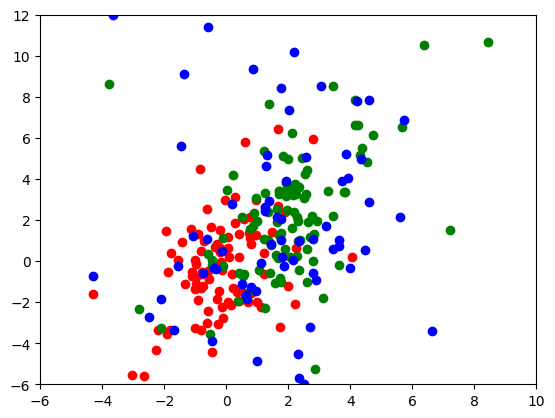

In [3]:
mu1 = np.array([0,0])
mu2 = np.array([2,2])
Sigma1 = np.array([[1,1], [1,4]])
Sigma2 = 4*Sigma1

MVS1 = rmvt(mu1, Sigma1, 5, 100)
MVS2 = rmvt(mu2, Sigma1, 3, 100)
MVS3 = rmvt(mu2, Sigma2, 1, 100)

# affichage
plt.figure()
plt.scatter(MVS1[:,0], MVS1[:,1], color= "red")
plt.scatter(MVS2[:,0], MVS2[:,1], color= "green")
plt.scatter(MVS3[:,0], MVS3[:,1], color= "blue")
plt.xlim(-6, 10)
plt.ylim(-6, 12)
plt.plot


In [4]:
Sigma3 = np.array([[1,1,1],[1,4,4],[1,4,9]])
mu3 = np.zeros(3)
data = rmvt(mu3, Sigma3, 5, 1000)

# matrice de projection
p = np.array([[1,1,1,1,1],[1,-1,1,-1,0],[0,-1,-1,0,2]])
norm = np.linalg.norm(p, axis=0) 

# projection
p_normalized = p/norm
projection = data @ p_normalized

# shift
shift = np.array([1, 2, 3, 4, 5])
projection_shifted = projection + shift

# ajout de bruit
noise = np.random.multivariate_normal(mean=np.zeros(5), cov=0.025*np.eye(5), size=1000)
projection_final = projection_shifted + noise

## PCA 

[2.80649722e+01 5.89643908e+00 2.11145430e+00 2.59897097e-02
 2.41828047e-02]
[167.44225055  76.74987062  45.92758267   5.09546072   4.9151421 ]
[[ 0.35036822 -0.58691041 -0.13155177 -0.21189277  0.68598387]
 [ 0.62334725  0.04531649  0.72380476 -0.20833558 -0.20515257]
 [ 0.25965763  0.45172841  0.08624362  0.69662619  0.48558558]
 [ 0.01391187  0.6657988  -0.14660551 -0.65110296  0.33330192]
 [-0.64889498 -0.07833257  0.65564447 -0.04974559  0.3747733 ]]


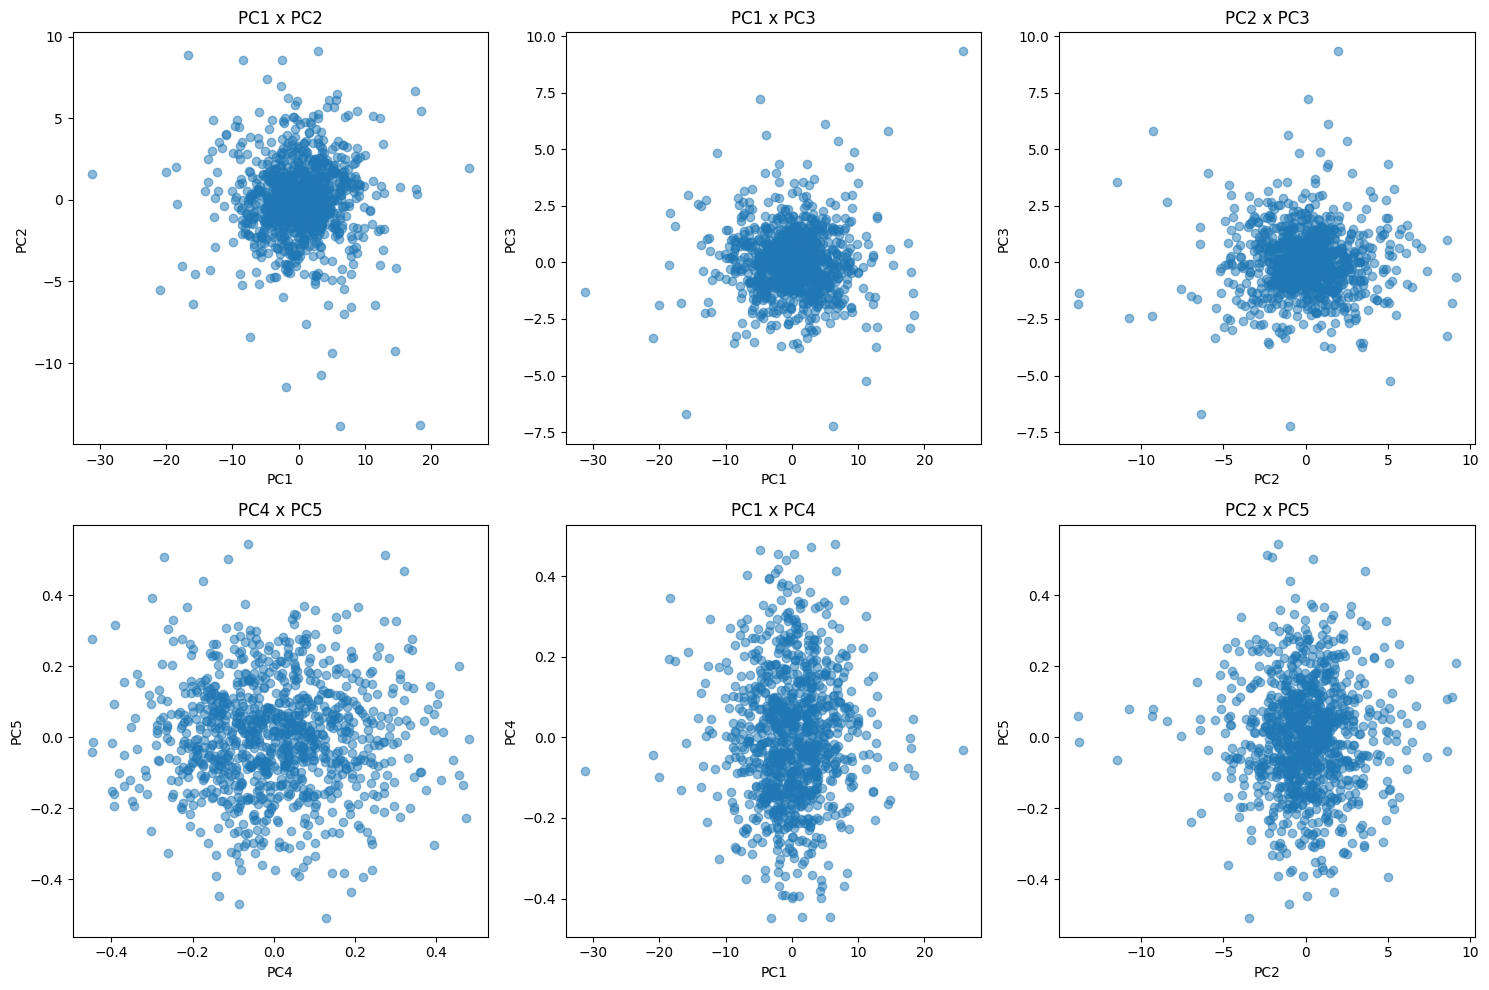

In [5]:
# PCA
pca = PCA(n_components=5)
data_pca = pca.fit_transform(projection_final)

# variance & singular values & full principal components
print(pca.explained_variance_)
print(pca.singular_values_)
print(pca.components_)

# affichage
fig, axs = plt.subplots(2, 3, figsize=(15, 10))

# PC1 x PC2
axs[0, 0].scatter(data_pca[:, 0], data_pca[:, 1], alpha=0.5)
axs[0, 0].set_xlabel('PC1')
axs[0, 0].set_ylabel('PC2')
axs[0, 0].set_title('PC1 x PC2')

# PC1 x PC3
axs[0, 1].scatter(data_pca[:, 0], data_pca[:, 2], alpha=0.5)
axs[0, 1].set_xlabel('PC1')
axs[0, 1].set_ylabel('PC3')
axs[0, 1].set_title('PC1 x PC3')

# PC2 x PC3
axs[0, 2].scatter(data_pca[:, 1], data_pca[:, 2], alpha=0.5)
axs[0, 2].set_xlabel('PC2')
axs[0, 2].set_ylabel('PC3')
axs[0, 2].set_title('PC2 x PC3')

# PC4 x PC5
axs[1, 0].scatter(data_pca[:, 3], data_pca[:, 4], alpha=0.5)
axs[1, 0].set_xlabel('PC4')
axs[1, 0].set_ylabel('PC5')
axs[1, 0].set_title('PC4 x PC5')

# PC1 x PC4
axs[1, 1].scatter(data_pca[:, 0], data_pca[:, 3], alpha=0.5)
axs[1, 1].set_xlabel('PC1')
axs[1, 1].set_ylabel('PC4')
axs[1, 1].set_title('PC1 x PC4')

# PC2 x PC5
axs[1, 2].scatter(data_pca[:, 1], data_pca[:, 4], alpha=0.5)
axs[1, 2].set_xlabel('PC2')
axs[1, 2].set_ylabel('PC5')
axs[1, 2].set_title('PC2 x PC5')

plt.tight_layout()
plt.show()


## Observations
Les premières composantes (PC1, PC2, PC3) sont celles qui expliquent le mieux la variance. Le graphe montre qu'elles traduisent le mieux la structure de nos données.  
Par contre, les 2 autres composantes (PC4, PC5) eux ne traduisent pas vraiment la structure, elles capturent plus le bruit.

## PCA via SVD

In [ ]:
# SVD 
data_centered = data - np.mean(data, axis=0)
U, S, Vt = np.linalg.svd(data_centered)

# composantes principales
principal_comp = Vt.T

# comparaison
print("composantes principales via SVD :")
print(principal_comp)




composantes principales via SVD :
[[ 0.12405186  0.34070903  0.93194876]
 [ 0.47201002  0.80587683 -0.35744801]
 [ 0.87282168 -0.48423124  0.06084756]]
